In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
df = pd.read_csv(r"C:\Users\HP\Downloads\House Price Prediction Dataset.csv")

In [7]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Floors     2000 non-null   int64 
 4   YearBuilt  2000 non-null   int64 
 5   Location   2000 non-null   object
 6   Condition  2000 non-null   object
 7   Garage     2000 non-null   object
 8   Price      2000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [9]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [10]:
df.columns = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt',
    'Location',
    'Condition',
    'Garage',
    'Price'
]

In [11]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.corr()['Price'].sort_values(ascending=False)

Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
Bathrooms   -0.015737
Name: Price, dtype: float64

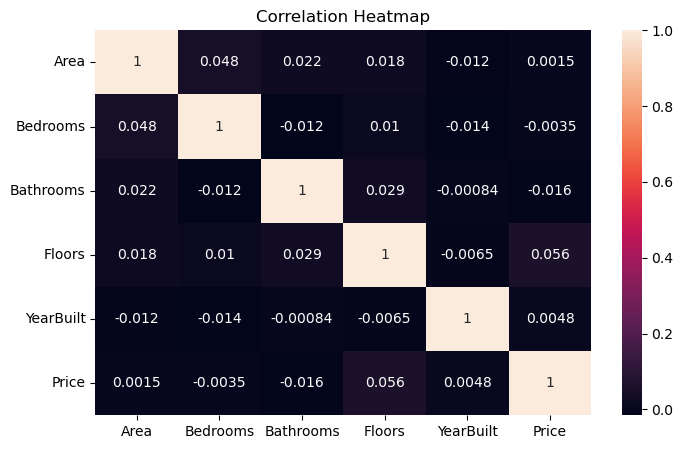

In [13]:
plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

In [14]:
X = df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']]

y = df['Price']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
predictions = model.predict(X_test)

In [19]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': predictions
})

comparison.head()

,Actual Price,Predicted Price
1860,514764,515577.200943
353,694256,544286.239952
1333,66375,504412.672222
905,650243,555773.690965
1289,223285,568830.772630


In [20]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 244587.19991978563
Mean Squared Error: 78789724000.88458
Root Mean Squared Error: 280695.0729900412
R2 Score: -0.01273663755401877


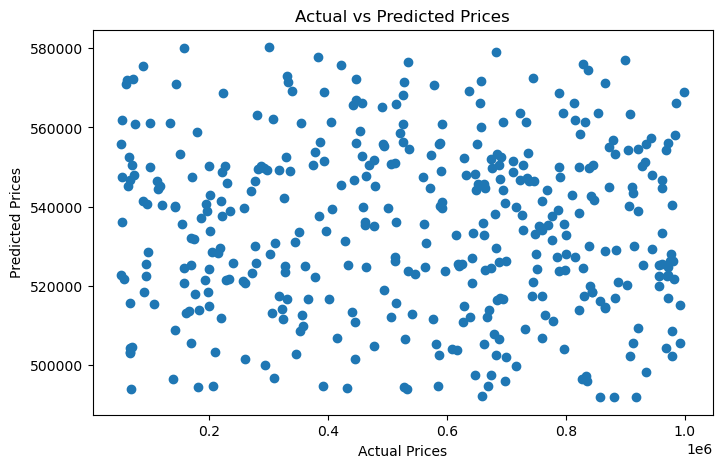

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [22]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,Area,-0.356816
1,Bedrooms,22.756660
2,Bathrooms,-9953.018569
3,Floors,23495.816306
4,YearBuilt,112.362393


# Predictive Analytics Insights

- The project demonstrates the complete predictive analytics workflow using historical housing data.
- Linear Regression was used to predict house prices based on property features such as area, bedrooms, bathrooms, floors, and year built.
- Data preprocessing and feature selection were performed before training the model.
- The model identified varying levels of influence among housing features.
- The dataset showed weak correlations between some variables and house prices, which affected prediction accuracy.
- Despite dataset limitations, the project successfully demonstrates regression modeling, prediction, evaluation metrics, and data visualization techniques.
- Predictive analytics can support data-driven decision-making in real estate pricing and market analysis.

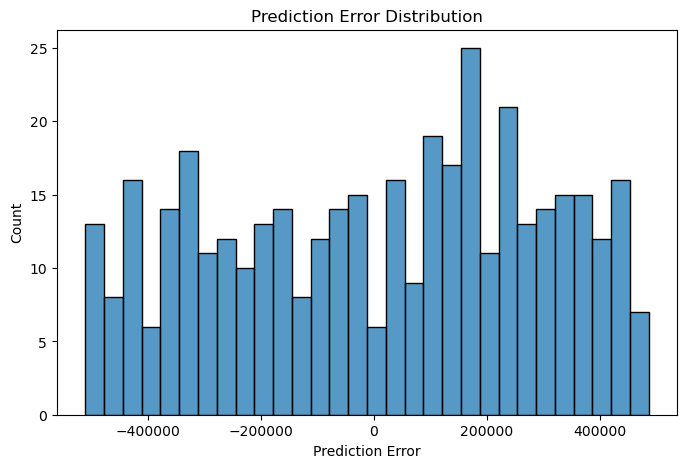

In [23]:
errors = y_test - predictions

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")

plt.show()